<a href="https://colab.research.google.com/github/nanditanair05-byte/CASE_STUDY_SUPERVISED_LEARNING/blob/main/case_study_supervised_learning_nandita.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('/content/drive/MyDrive/DSA/supervised learning/case study_supervised learning/Training_data.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [160]:
df.shape

(5634, 21)

In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [162]:
df.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [163]:
df.duplicated().sum()

np.int64(0)

In [164]:
#handling missing values
df.value_counts('gender')

,count
gender,
Male,2744
Female,2721


In [165]:
df['gender'].fillna('Unknown', inplace=True)

/tmp/ipykernel_913/1405829346.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gender'].fillna('Unknown', inplace=True)


In [166]:
df.value_counts('OnlineSecurity')

,count
OnlineSecurity,
No,2720
Yes,1574
No internet service,1171


<Axes: xlabel='OnlineSecurity', ylabel='Count'>

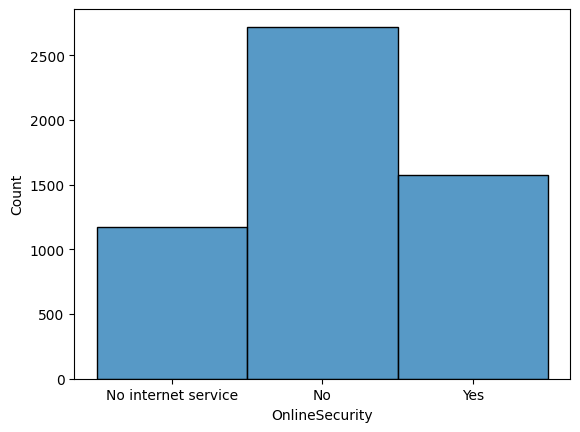

In [167]:
sns.histplot(df['OnlineSecurity'])

In [168]:
df['OnlineSecurity'].fillna(df['OnlineSecurity'].mode()[0], inplace=True)

/tmp/ipykernel_913/3727459259.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['OnlineSecurity'].fillna(df['OnlineSecurity'].mode()[0], inplace=True)


In [169]:
df.value_counts('MonthlyCharges')

,count
MonthlyCharges,
20.05,44
19.65,38
19.90,36
19.70,34
20.00,33
...,...
116.15,1
116.10,1
116.00,1


<Axes: xlabel='MonthlyCharges', ylabel='Count'>

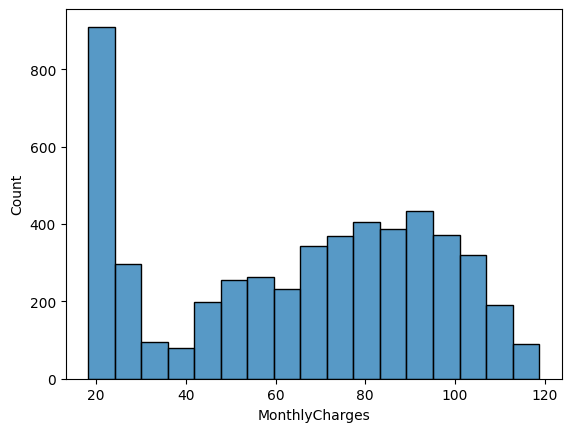

In [170]:
sns.histplot(df['MonthlyCharges'])

In [171]:
df['MonthlyCharges']=df['MonthlyCharges'].fillna(df['MonthlyCharges'].median())

In [172]:
df.value_counts('TotalCharges')

,count
TotalCharges,
,9
19.65,8
20.2,8
19.75,7
19.9,7
...,...
262.3,1
262.05,1
2619.25,1


In [173]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

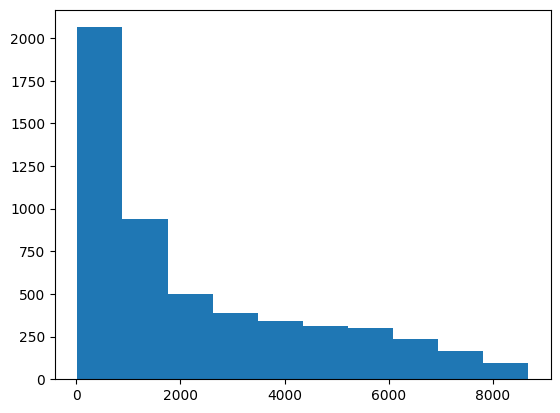

In [174]:
plt.hist(df['TotalCharges'])
plt.show()

In [175]:
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].median())

In [176]:
#checking outliers
numerical_col = df.select_dtypes(include='number').columns

print(numerical_col)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


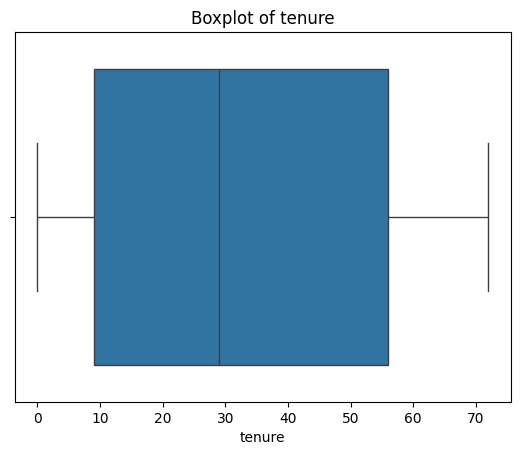

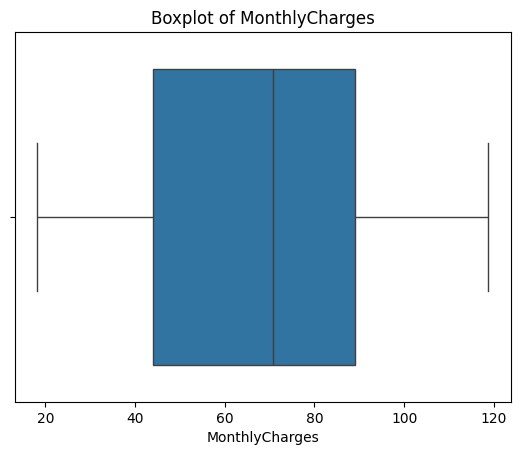

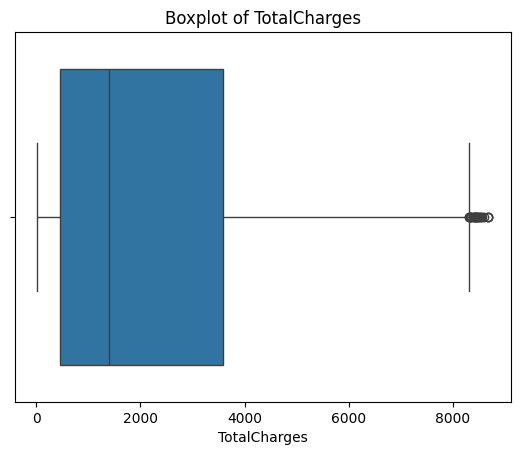

In [177]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numerical_cols:
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [178]:
#encoding
binary_cols = [
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]

for col in binary_cols:
    df[col] = df[col].map({'No': 0, 'Yes': 1})

In [179]:
one_hot_cols = [
    'gender',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'PaymentMethod'
]

df = pd.get_dummies(
    df,
    columns=one_hot_cols,
    drop_first=True,
    dtype=int
)

In [180]:
df.value_counts('Contract')

,count
Contract,
Month-to-month,3094
Two year,1368
One year,1172


In [181]:
df = pd.get_dummies(df, columns=['Contract'], drop_first=True, dtype=int)

In [182]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 33 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             5634 non-null   object 
 1   SeniorCitizen                          5634 non-null   int64  
 2   Partner                                5634 non-null   int64  
 3   Dependents                             5634 non-null   int64  
 4   tenure                                 5634 non-null   int64  
 5   PhoneService                           5634 non-null   int64  
 6   PaperlessBilling                       5634 non-null   int64  
 7   MonthlyCharges                         5634 non-null   float64
 8   TotalCharges                           5634 non-null   float64
 9   Churn                                  5634 non-null   int64  
 10  gender_Male                            5634 non-null   int64  
 11  gend

In [183]:
#spliting x and y
X=df.drop(['Churn','customerID'],axis=1)
Y=df['Churn']

In [184]:
#feature engineering
X['CustomerLifetimeValue'] = X['tenure'] * X['MonthlyCharges']

In [185]:
print(X[['tenure', 'MonthlyCharges', 'CustomerLifetimeValue']].head())

   tenure  MonthlyCharges  CustomerLifetimeValue
0      35           20.75                 726.25
1      28           35.75                1001.00
2      56           98.60                5521.60
3      39           20.45                 797.55
4      43           51.25                2203.75


In [186]:
X['Tenure_OneYear'] = X['tenure'] * X['Contract_One year']

X['Tenure_TwoYear'] = X['tenure'] * X['Contract_Two year']

In [187]:
print(X[['tenure',
         'Contract_One year',
         'Contract_Two year',
         'CustomerLifetimeValue',
         'Tenure_OneYear',
         'Tenure_TwoYear']].head())

   tenure  Contract_One year  Contract_Two year  CustomerLifetimeValue  \
0      35                  1                  0                 726.25   
1      28                  0                  0                1001.00   
2      56                  0                  0                5521.60   
3      39                  0                  1                 797.55   
4      43                  1                  0                2203.75   

   Tenure_OneYear  Tenure_TwoYear  
0              35               0  
1               0               0  
2               0               0  
3               0              39  
4              43               0  


In [188]:
#splitting
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [189]:
#balancing the data
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)

X_train_balanced, y_train_balanced = ros.fit_resample(
    X_train,
    Y_train
)
print(y_train_balanced.value_counts())

Churn
0    3304
1    3304
Name: count, dtype: int64


In [190]:
#feature seletion
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_balanced, y_train_balanced)

RandomForestClassifier(random_state=42)

In [191]:

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train_balanced.columns
).sort_values(ascending=False)

print(feature_importance.head(15))

TotalCharges                      0.126943
CustomerLifetimeValue             0.124185
tenure                            0.118746
MonthlyCharges                    0.111617
Tenure_TwoYear                    0.044231
InternetService_Fiber optic       0.038760
Contract_Two year                 0.038749
Tenure_OneYear                    0.034100
PaymentMethod_Electronic check    0.032009
OnlineSecurity_Yes                0.022473
Contract_One year                 0.021996
gender_Male                       0.020540
TechSupport_Yes                   0.020367
PaperlessBilling                  0.019670
OnlineBackup_Yes                  0.017648
dtype: float64


In [192]:
#scaling
from sklearn.preprocessing import StandardScaler

numerical_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'CustomerLifetimeValue',
    'Tenure_OneYear',
    'Tenure_TwoYear'
]

scaler = StandardScaler()

X_train_balanced[numerical_cols] = scaler.fit_transform(
    X_train_balanced[numerical_cols]
)

X_test[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)

In [193]:
#model
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
log_model.fit(X_train_balanced, y_train_balanced)

LogisticRegression(max_iter=1000, random_state=42)

In [194]:
y_pred_log = log_model.predict(X_test)

In [195]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

y_prob_log = log_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(Y_test, y_pred_log))
print("Precision:", precision_score(Y_test, y_pred_log))
print("Recall   :", recall_score(Y_test, y_pred_log))
print("F1 Score :", f1_score(Y_test, y_pred_log))
print('confusion matrix')
print(confusion_matrix(Y_test, y_pred_log))

Accuracy : 0.7568766637089619
Precision: 0.5302013422818792
Recall   : 0.7873754152823921
F1 Score : 0.6336898395721925
confusion matrix
[[616 210]
 [ 64 237]]


In [196]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(
    n_neighbors=5
)
knn_model.fit(
    X_train_balanced,
    y_train_balanced
)

KNeighborsClassifier()

In [197]:
y_pred_knn = knn_model.predict(X_test)

In [198]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
   confusion_matrix
)

y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(Y_test, y_pred_knn))
print("Precision:", precision_score(Y_test, y_pred_knn))
print("Recall   :", recall_score(Y_test, y_pred_knn))
print("F1 Score :", f1_score(Y_test, y_pred_knn))
print('confusion matrix')
print(confusion_matrix(Y_test, y_pred_knn))

Accuracy : 0.7329192546583851
Precision: 0.5
Recall   : 0.7840531561461794
F1 Score : 0.610608020698577
confusion matrix
[[590 236]
 [ 65 236]]


In [199]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train_balanced,
    y_train_balanced
)

RandomForestClassifier(random_state=42)

In [200]:
y_pred_rf = rf_model.predict(X_test)

In [201]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(Y_test, y_pred_log))
print("Precision:", precision_score(Y_test, y_pred_log))
print("Recall   :", recall_score(Y_test, y_pred_log))
print("F1 Score :", f1_score(Y_test, y_pred_log))
print('confusion matrix')
print(confusion_matrix(Y_test, y_pred_log))

Accuracy : 0.7568766637089619
Precision: 0.5302013422818792
Recall   : 0.7873754152823921
F1 Score : 0.6336898395721925
confusion matrix
[[616 210]
 [ 64 237]]


In [202]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(
    X_train_balanced,
    y_train_balanced
)

y_pred_gb = gb_model.predict(X_test)

In [203]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(Y_test, y_pred_gb))
print("Precision:", precision_score(Y_test, y_pred_gb))
print("Recall   :", recall_score(Y_test, y_pred_gb))
print("F1 Score :", f1_score(Y_test, y_pred_gb))
print('confusion matrix')
print(confusion_matrix(Y_test, y_pred_gb))

Accuracy : 0.7675244010647737
Precision: 0.5444191343963554
Recall   : 0.7940199335548173
F1 Score : 0.6459459459459459
confusion matrix
[[626 200]
 [ 62 239]]


In [112]:
#model fine tuning
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    random_state=42
)

param_dist = {
    'n_estimators': [50, 100, 150, 200, 250, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

random_search_gb = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)
random_search_gb.fit(
    X_train_balanced,
    y_train_balanced
)

RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1, 0.15,
                                                          0.2],
                                        'max_depth': [2, 3, 4, 5],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 150, 200, 250,
                                                         300]},
                   random_state=42, scoring='f1')

In [205]:
print("Best Parameters:")
print(random_search_gb.best_params_)
best_gb_random = random_search_gb.best_estimator_
y_pred_gb_random = best_gb_random.predict(X_test)

print("Accuracy :", accuracy_score(Y_test, y_pred_gb_random))
print("Precision:", precision_score(Y_test, y_pred_gb_random))
print("Recall   :", recall_score(Y_test, y_pred_gb_random))
print("F1 Score :", f1_score(Y_test, y_pred_gb_random))

Best Parameters:
{'n_estimators': 250, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 5, 'learning_rate': 0.2}
Accuracy : 0.7843833185448092
Precision: 0.5911949685534591
Recall   : 0.6245847176079734
F1 Score : 0.6074313408723748


 7. Model Selection

Gradient Boosting was selected as the final model because it achieved the highest Recall 79.40% and F1-score 64.59% among the evaluated models. Although Random Forest achieved the highest Accuracy 79.50%, Recall was considered more important because the primary objective of churn prediction is to correctly identify customers who are likely to leave.

Hyperparameter tuning using RandomizedSearchCV improved the model's accuracy but resulted in lower Recall and F1-score. Therefore, the original Gradient Boosting model was retained as the final model, as it provided better performance for identifying potential churn customers.

 8. Conclusion

This project focused on predicting telecom customer churn using Exploratory Data Analysis EDA, data preprocessing, feature engineering, class balancing, and machine learning techniques. Four classification models—Logistic Regression, Random Forest, Gradient Boosting, and KNN—were developed and evaluated.
Key Findings

Random Forest achieved the highest Accuracy of 79.50%.
Gradient Boosting achieved the highest Recall of 79.40% and F1-score of 64.59%.
 Gradient Boosting was selected as the final model because correctly identifying potential churn customers was the primary objective.

Hyperparameter tuning improved Accuracy but reduced Recall and F1-score. Hence, the original Gradient Boosting model was retained** as the final model.


In [ ]:
#testing
test_df = pd.read_csv("/content/drive/MyDrive/DSA/supervised learning/case study_supervised learning/Testing_data.csv")

test_df.head()

In [ ]:
test_df.shape

In [ ]:
test_df.columns.tolist()

In [ ]:
test_df.isnull().sum()

In [ ]:
y_new = test_df['Churn'].map({
    'No': 0,
    'Yes': 1
})
y_new.value_counts()

In [ ]:
X_new = test_df.drop(
    ['Churn', 'customerID'],
    axis=1
)
X_new.head()

In [ ]:
binary_cols = [
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

for col in binary_cols:
    X_new[col] = X_new[col].map({
        'No': 0,
        'Yes': 1
    })
X_new[binary_cols].head()

In [ ]:
categorical_cols = [
    'gender',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'PaymentMethod',
    'Contract'
]

X_new = pd.get_dummies(
    X_new,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)
print(X_new.shape)
print(X_new.columns.tolist())

In [ ]:
X_new['CustomerLifetimeValue'] = (
    X_new['tenure'] * X_new['MonthlyCharges']
)

X_new['Tenure_OneYear'] = (
    X_new['tenure'] * X_new['Contract_One year']
)

X_new['Tenure_TwoYear'] = (
    X_new['tenure'] * X_new['Contract_Two year']
)

In [ ]:
X_new = X_new.reindex(
    columns=X.columns,
    fill_value=0
)
print(X_new.shape)
print(X_new.columns.equals(X.columns))

In [ ]:
X_new['TotalCharges'] = pd.to_numeric(
    X_new['TotalCharges'],
    errors='coerce'
)

In [ ]:
print(X_new['TotalCharges'].isna().sum())

In [ ]:
X_new['TotalCharges'] = X_new['TotalCharges'].fillna(
    X_train_balanced['TotalCharges'].median()
)

In [ ]:
print(X_new['TotalCharges'].isna().sum())

In [ ]:
numerical_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'CustomerLifetimeValue',
    'Tenure_OneYear',
    'Tenure_TwoYear'
]

X_new[numerical_cols] = scaler.transform(
    X_new[numerical_cols]
)

In [207]:
y_pred_new = gb_model.predict(X_new)

In [208]:
print(y_pred_new[:20])

[1 0 1 0 0 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0]


In [209]:
print(pd.Series(y_pred_new).value_counts())

0    862
1    547
Name: count, dtype: int64


In [210]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_new, y_pred_new))
print("Precision:", precision_score(y_new, y_pred_new))
print("Recall   :", recall_score(y_new, y_pred_new))
print("F1 Score :", f1_score(y_new, y_pred_new))

print("\nConfusion Matrix:")
print(confusion_matrix(y_new, y_pred_new))

Accuracy : 0.7374024130589071
Precision: 0.4954296160877514
Recall   : 0.7424657534246575
F1 Score : 0.5942982456140351

Confusion Matrix:
[[768 276]
 [ 94 271]]


In [211]:
results = test_df[['customerID']].copy()

results['Actual_Churn'] = y_new
results['Predicted_Churn'] = y_pred_new

results.head()

,customerID,Actual_Churn,Predicted_Churn
0,6080-TCMYC,0,1
1,7285-KLOTR,0,0
2,7486-KSRVI,1,1
3,9924-JPRMC,0,0
4,4439-YRNVD,0,0


The model was tested on 1,409 new customers and achieved 73.74% accuracy. It correctly identified 271 out of 365 customers who actually churned. This shows that the model can identify many customers who are likely to leave, but some predictions were still incorrect.